
<font color="purple" size="6"><b>Advanced Exploratory Data Analysis (EDA)</b></font>
<br>

This Section performs advanced exploratory data analysis across the SaaS dataset.

The goal is to identify patterns in customer behavior, product usage,
support activity and revenue outcomes.

The analysis covers the following requirements:

- Univariate and bivariate analysis across all 6 datasets
- Correlation analysis between support ticket volume and renewal outcome
- Usage pattern segmentation
- NPS analysis with discussion of **non‑response bias (34% response rate)**
- At least **10 publication‑quality visualizations**
- Clear **business interpretation after each visualization**

Datasets used:

- `accounts_dim`
- `usage_dim`
- `support_dim`
- `nps_dim`
- `renewals_fact`
- `invoices_fact`

<font color="purple" size="4"><b>Import Libraries</b></font>

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.style.use("ggplot")

<font color="purple" size="4"><b>Load Data from SQLite Database</b></font>

In [2]:
# Load data from SQLite database

import sqlite3

conn = sqlite3.connect("../Data/data_cleaned.db")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(tables)

[('accounts_dim',), ('usage_dim',), ('support_dim',), ('nps_dim',), ('renewals_fact',), ('invoices_fact',)]


In [3]:
# Load tables into pandas DataFrames

conn = sqlite3.connect("../Data/data_cleaned.db")

accounts = pd.read_sql("SELECT * FROM accounts_dim", conn)
usage = pd.read_sql("SELECT * FROM usage_dim", conn)
support = pd.read_sql("SELECT * FROM support_dim", conn)
nps = pd.read_sql("SELECT * FROM nps_dim", conn)

renewals = pd.read_sql("SELECT * FROM renewals_fact", conn)
invoices = pd.read_sql("SELECT * FROM invoices_fact", conn)

<font color="purple" size="4"><b>Dataset Overview</b></font>

The dataset consists of six tables:

• Accounts — customer attributes and segmentation  
• Usage — product engagement metrics  
• Renewals — contract renewal outcomes and ARR values  
• Support — customer support activity  
• NPS — customer satisfaction survey responses  
• Invoices — billing and payment behavior

In [4]:
accounts.head()

,account_id,company,tier,region,arr,contract_start,contract_end,account_manager
0,1,"Jones, Snyder and Bass",Business,APAC,15860,2024-04-07,2025-04-07,Christopher Green
1,2,Frost Inc,Business,Europe,20191,2024-07-31,2025-07-31,Shelby Miller
2,3,"Herrera, Adkins and Andersen",Starter,North America,3638,2024-06-03,2025-06-03,Wesley Reyes
3,4,Berry-Lee,Business,APAC,28526,2025-02-06,2026-02-06,Kevin Jimenez DVM
4,5,Martin Inc,Business,Europe,29423,2024-06-06,2025-06-06,Michael Cruz


In [5]:
usage.head()

,event_id,account_id,week_start,tier,feature,usage_count
0,1,1,2024-01-01,Business,dashboard,14.0
1,2,1,2024-01-01,Business,reports,10.0
2,3,1,2024-01-01,Business,automation,7.0
3,4,1,2024-01-01,Business,integrations,3.0
4,5,1,2024-01-08,Business,dashboard,13.0


In [6]:
support.head()

,ticket_id,account_id,created_at,category,resolution_hours,sentiment_score
0,1,112.0,2025-05-11,performance,62,-0.910419
1,2,106.0,2025-06-20,performance,16,-0.252450
2,3,281.0,2025-04-29,feature_request,33,0.148413
3,4,246.0,2025-06-01,integration,24,-0.319757
4,5,459.0,2025-12-06,billing,9,0.401519


In [7]:
renewals.head()

,renewal_id,account_id,renewal_date,previous_arr,new_arr,outcome
0,1,1,2025-01-01,15860,15860.00,renewed
1,2,2,2025-01-01,20191,20191.00,renewed
2,3,3,2025-01-01,3638,2718.29,downgraded
3,4,4,2025-01-01,28526,0.00,churned
4,5,5,2025-01-01,29423,29423.00,renewed


In [8]:
nps.head()

,survey_id,account_id,score,survey_date
0,1,6,10,2024-12-01
1,2,8,1,2024-12-01
2,3,10,10,2024-12-01
3,4,11,1,2024-12-01
4,5,16,7,2024-12-01


In [9]:
invoices.head()

,invoice_id,account_id,invoice_date,due_date,paid_date,amount,currency,discount_code,payment_terms
0,INV1,1,2024-01-01,2024-01-31,2024-02-01,1215.9364,EUR,PROMO10,Net 60
1,INV2,1,2024-02-01,2024-03-02,2024-03-08,1321.6700,EUR,LOYALTY15,Net 15
2,INV3,1,2024-03-01,2024-03-31,2024-04-01,1321.6700,EUR,No_Discount,Net 30
3,INV4,1,2024-04-01,2024-05-01,2024-04-27,1321.6700,EUR,PROMO10,Net 15
4,INV5,1,2024-05-01,2024-05-31,2024-06-08,1215.9364,EUR,SUMMER20,Net 15


<font color="purple" size="5"><b>Univariate Analysis</b></font>

<font color="purple" size="4"><b>ARR Distribution</b></font>

Annual Recurring Revenue (ARR) is the most important metric in SaaS businesses.
Understanding how ARR is distributed across accounts helps identify revenue concentration.

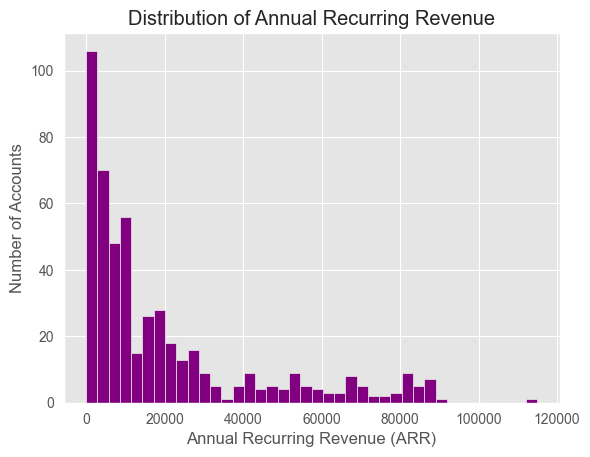

In [10]:
plt.figure()

renewals["new_arr"].hist(bins=40,color="purple")

plt.title("Distribution of Annual Recurring Revenue")

plt.xlabel("Annual Recurring Revenue (ARR)")

plt.ylabel("Number of Accounts")

plt.show()

<font color="orange" size="4"><b>Business Insight:</b></font>


ARR distribution is highly skewed with a small number of large enterprise customers generating a disproportionate share of revenue and the majority of customers generate relatively small revenue.

This suggests that the company may be reliant on a few key accounts, which could pose a risk if any of those customers churn. The long tail of smaller accounts indicates a large base of lower-revenue customers, which may require different retention strategies compared to the high-value accounts.

This is a common SaaS pattern known as **revenue concentration**, where enterprise customers drive a large portion of total ARR.

<font color="purple" size="4"><b>Support Ticket Distribution</b></font>

Each row in the support dataset represents a support ticket.  
To analyze support load per customer account, we aggregate the number of tickets per account.

In [13]:
# Create a new column for ticket count per account

ticket_counts = support.groupby("account_id").size().reset_index(name="ticket_count")

ticket_counts.head()

,account_id,ticket_count
0,2.0,4
1,3.0,2
2,4.0,4
3,5.0,2
4,6.0,3


In [14]:
# Merge ticket counts back to accounts to analyze support load per account

accounts = accounts.merge(ticket_counts, on="account_id", how="left")
accounts["ticket_count"] = accounts["ticket_count"].fillna(0)
accounts.head()




,account_id,company,tier,region,arr,contract_start,contract_end,account_manager,ticket_count
0,1,"Jones, Snyder and Bass",Business,APAC,15860,2024-04-07,2025-04-07,Christopher Green,0.0
1,2,Frost Inc,Business,Europe,20191,2024-07-31,2025-07-31,Shelby Miller,4.0
2,3,"Herrera, Adkins and Andersen",Starter,North America,3638,2024-06-03,2025-06-03,Wesley Reyes,2.0
3,4,Berry-Lee,Business,APAC,28526,2025-02-06,2026-02-06,Kevin Jimenez DVM,4.0
4,5,Martin Inc,Business,Europe,29423,2024-06-06,2025-06-06,Michael Cruz,2.0


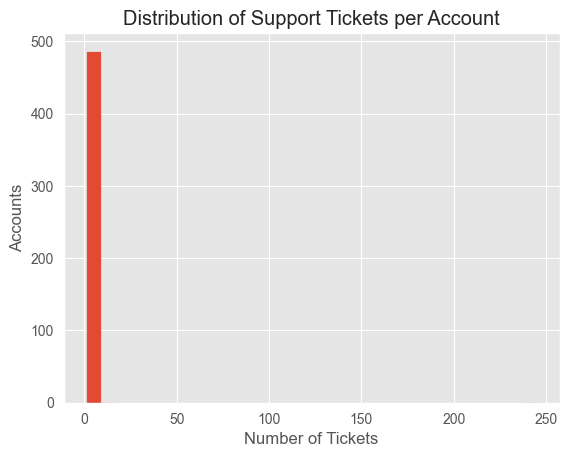

In [15]:
plt.figure()

ticket_counts["ticket_count"].hist(bins=30)

plt.title("Distribution of Support Tickets per Account")

plt.xlabel("Number of Tickets")

plt.ylabel("Accounts")

plt.show()

<font color="orange" size="4"><b>Business Insight:</b></font>

Most customers generate relatively few support tickets, suggesting that the product is generally stable and easy to use.

However, a subset of customers generates a significantly higher number of tickets. These customers may require additional onboarding, product improvements, or dedicated support.


<font color="purple" size="4"><b>Support Resolution Time Analysis</b></font>

Understanding how long support tickets take to resolve helps evaluate support efficiency.

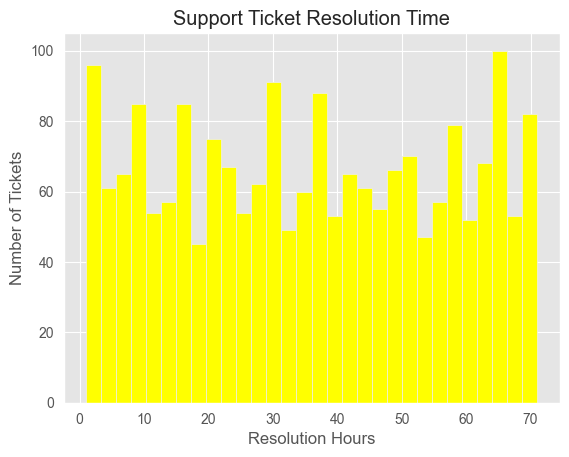

In [16]:
plt.figure()

support["resolution_hours"].hist(bins=30, color="yellow")

plt.title("Support Ticket Resolution Time")

plt.xlabel("Resolution Hours")

plt.ylabel("Number of Tickets")

plt.show()

<font color="orange" size="4"><b>Business Insight:</b></font>

Most tickets are resolved quickly, which indicates an efficient support operation.

However, a long tail of high-resolution times suggests that some issues are more complex and may require engineering intervention.


<font color="purple" size="4"><b>Support Sentiment Analysis</b></font>

Sentiment scores indicate how positive or negative customer interactions were with support.

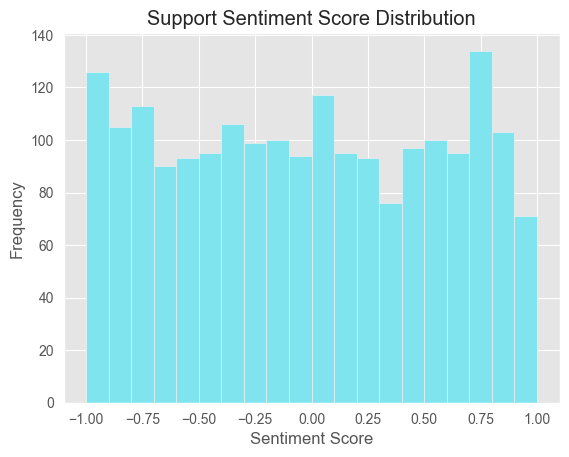

In [17]:
plt.figure()

support["sentiment_score"].hist(bins=20,color="#80E4EF")

plt.title("Support Sentiment Score Distribution")

plt.xlabel("Sentiment Score")

plt.ylabel("Frequency")

plt.show()

<font color="purple" size="4"><b>Product Usage per Account</b></font>

Product engagement is a strong predictor of customer retention in SaaS businesses.

We aggregate product usage per account to measure overall engagement.

In [18]:
# Product engagement is measured by aggregating usage events per account.

usage_per_account = usage.groupby("account_id")["usage_count"].sum().reset_index()

usage_per_account.head()

,account_id,usage_count
0,1,2186.0
1,2,2080.0
2,3,1047.0
3,4,2011.0
4,5,2072.0


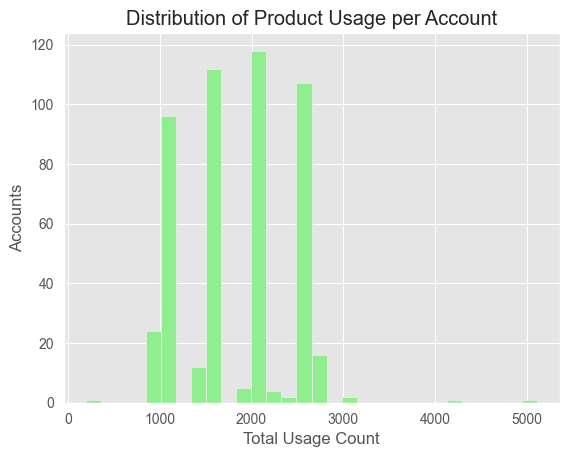

In [19]:
 
plt.figure()

usage_per_account["usage_count"].hist(bins=30,color="lightgreen")

plt.title("Distribution of Product Usage per Account")

plt.xlabel("Total Usage Count")

plt.ylabel("Accounts")

plt.show()

<font color="orange" size="4"><b>Business Insight:</b></font>

Accounts with higher product usage are generally more engaged with the product.

Higher engagement often correlates with stronger renewals and lower churn risk.

<font color="purple" size="4"><b>NPS Score Distribution</b></font>

Net Promoter Score (NPS) measures customer satisfaction and loyalty.

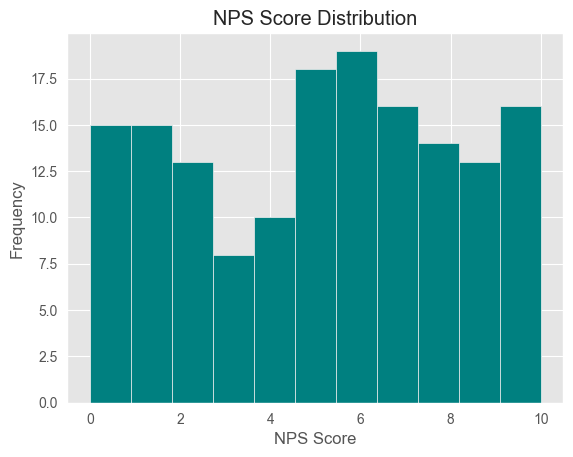

In [20]:
plt.figure()

nps["score"].hist(bins=11,color="teal")

plt.title("NPS Score Distribution")

plt.xlabel("NPS Score")
plt.ylabel("Frequency")

plt.show()


<font color="orange" size="4"><b>Business Insight:</b></font>

NPS scores help categorize customers into promoters, passives and detractors.

The distribution provides an overview of overall customer sentiment.


<font color="purple" size="4"><b>Invoice Payment Delay</b></font>

Late payments may indicate financial stress or dissatisfaction, which could correlate with churn risk.

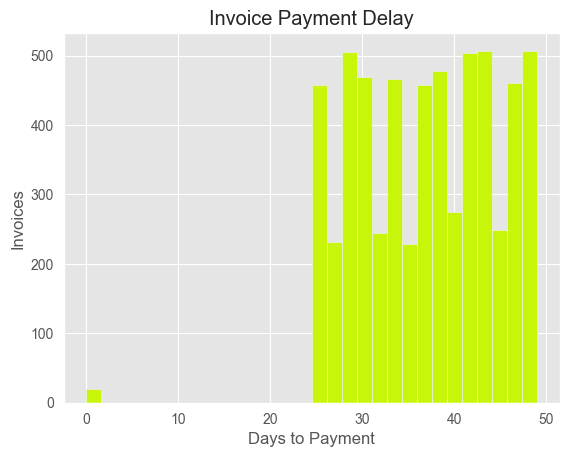

In [21]:
invoices["invoice_date"] = pd.to_datetime(invoices["invoice_date"])
invoices["paid_date"] = pd.to_datetime(invoices["paid_date"])

invoices["payment_delay"] = (invoices["paid_date"] - invoices["invoice_date"]).dt.days

plt.figure()

invoices["payment_delay"].hist(bins=30,color="#C7F60B")

plt.title("Invoice Payment Delay")
plt.xlabel("Days to Payment")
plt.ylabel("Invoices")

plt.show()


<font color="orange" size="4"><b>Business Insight:</b></font>

Long payment delays may indicate financial stress or operational inefficiencies within customer organizations.

These accounts may require proactive monitoring to reduce potential churn risk.

<font color="purple" size="5"><b>Bivariate analysis</b></font>

<font color="purple" size="4"><b>ARR by Region</b></font>

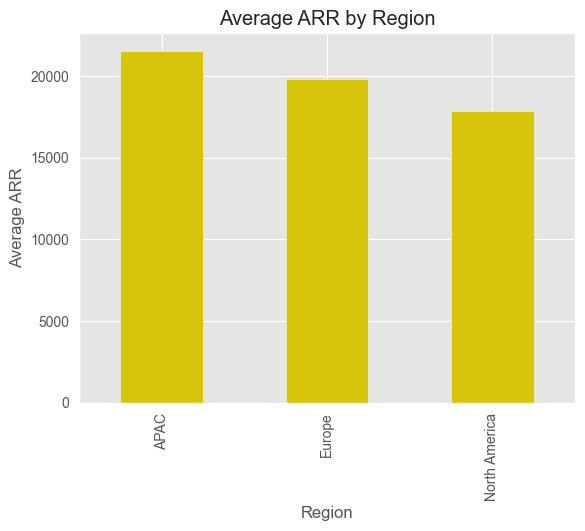

In [22]:
region_data = renewals.merge(accounts, on="account_id")

plt.figure()

region_data.groupby("region")["new_arr"].mean().plot(kind="bar",color="#d6c50a")

plt.title("Average ARR by Region")

plt.xlabel("Region")

plt.ylabel("Average ARR")

plt.show()

<font color="orange" size="4"><b>Business Insights:</b></font>

Regional performance differences may highlight market opportunities or localized product adoption trends.

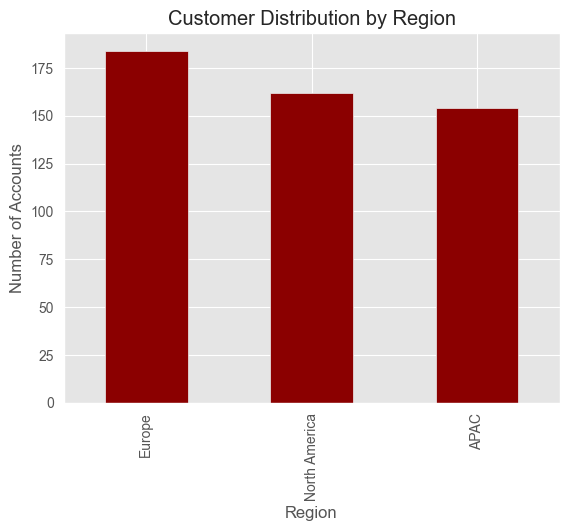

In [23]:
plt.figure()

accounts["region"].value_counts().plot(kind="bar",color="darkred")

plt.title("Customer Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Accounts")

plt.show()

<font color="orange" size="4"><b>Business Insight:</b></font>

Customer distribution varies across regions.
This may reflect differences in market penetration or regional sales strategy.


<font color="purple" size="4"><b>Support Tickets vs Renewal ARR</b></font>

We investigate whether accounts with more support tickets have different renewal outcomes.

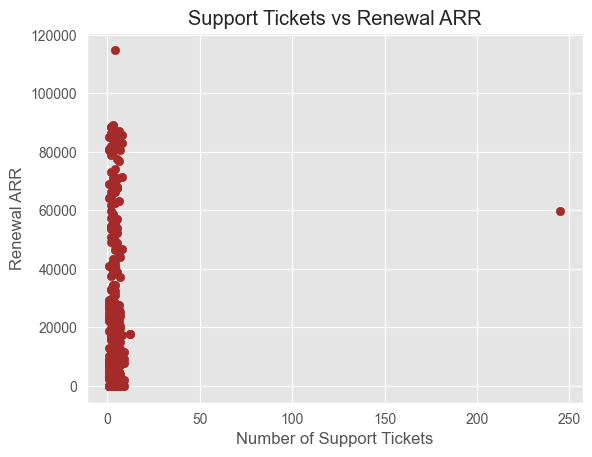

In [25]:
support_renewals = ticket_counts.merge(renewals, on="account_id")

# Calculate correlation between ticket count and renewal ARR
plt.figure()

plt.scatter(
    support_renewals["ticket_count"],
    support_renewals["new_arr"], color="brown"
)

plt.xlabel("Number of Support Tickets")

plt.ylabel("Renewal ARR")

plt.title("Support Tickets vs Renewal ARR")

plt.show()

In [26]:
# Calculate correlation between ticket count and renewal ARR

support_renewals[["ticket_count","new_arr"]].corr()

,ticket_count,new_arr
ticket_count,1.00000,0.07419
new_arr,0.07419,1.00000


<font color="orange" size="4"><b>Business Insight:</b></font>

Customers generating a high number of support tickets may be experiencing operational issues or product challenges.

If these customers also show lower renewal ARR, this may indicate that **support burden is associated with churn risk**.

<font color="purple" size="4"><b>Product Usage vs Renewal Revenue</b></font>

Higher product engagement may lead to stronger renewals.

In [27]:
# Higher product engagement may lead to stronger renewals.

usage_renewals = usage_per_account.merge(renewals, on="account_id")

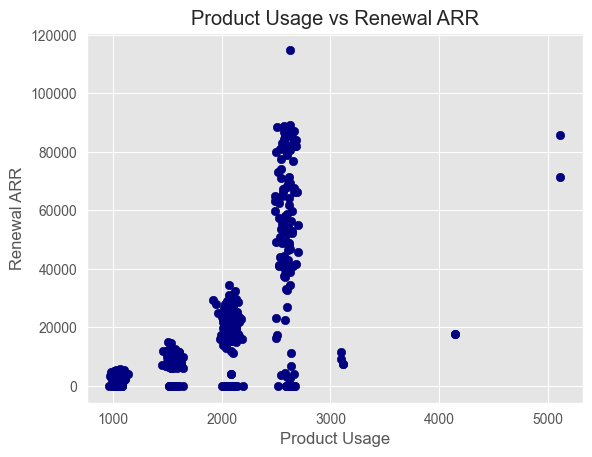

In [28]:
# Calculate correlation between usage count and renewal ARR

plt.figure()

plt.scatter(
    usage_renewals["usage_count"],
    usage_renewals["new_arr"], color="navy"
)

plt.xlabel("Product Usage")

plt.ylabel("Renewal ARR")

plt.title("Product Usage vs Renewal ARR")

plt.show()

<font color="purple" size="4"><b>NPS vs Renewal ARR</b></font>

Customers with higher NPS scores may be more likely to renew and expand.

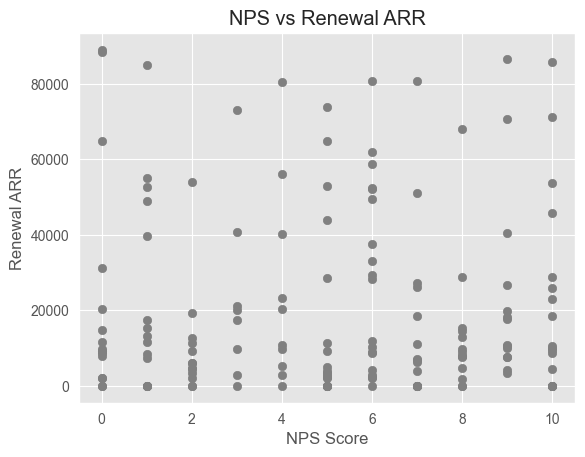

In [29]:
nps_renewals = nps.merge(renewals, on="account_id")

plt.figure()

plt.scatter(
    nps_renewals["score"],
    nps_renewals["new_arr"], color="gray"
)

plt.xlabel("NPS Score")

plt.ylabel("Renewal ARR")

plt.title("NPS vs Renewal ARR")

plt.show()

<font color="purple" size="4"><b>ARR by Customer Tier</b></font>

Different customer tiers may generate different levels of revenue.

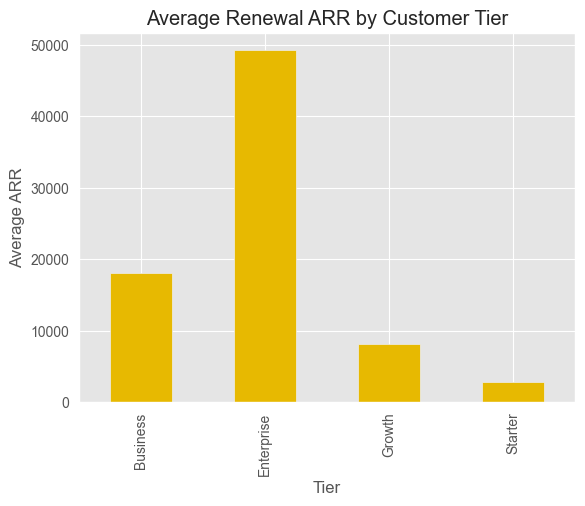

In [30]:
plt.figure()

region_data.groupby("tier")["new_arr"].mean().plot(kind="bar",color="#E7B901")

plt.title("Average Renewal ARR by Customer Tier")

plt.xlabel("Tier")

plt.ylabel("Average ARR")

plt.show()

<font color="purple" size="5"><b>Bias Analysis</b></font>

<font color="purple" size="4"><b>NPS Non‑Response Bias</b></font>

Only **34% of customers responded** to the NPS survey.

This introduces potential **non‑response bias**, meaning respondents may not represent the entire customer base.

This bias can skew insights derived from NPS data, as those who respond may have stronger opinions (positive or negative) than non-respondents.

When interpreting NPS results, it's important to consider this limitation and avoid overgeneralizing findings to all customers.

c:\Users\mobas\Documents\Greenbootcamp\SaaS-Revenue-Churn-Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


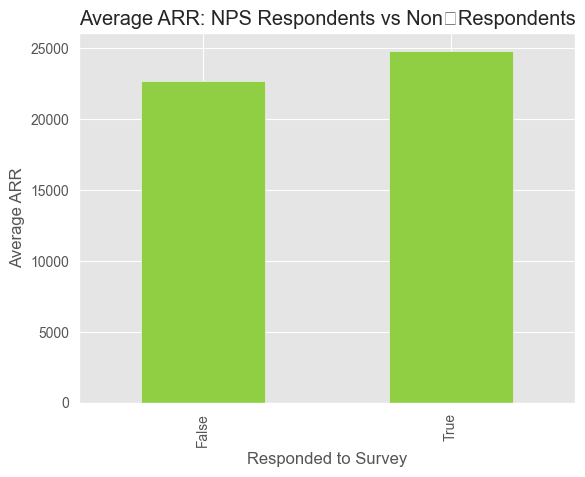

In [34]:
accounts_nps = accounts.merge(nps, on="account_id", how="left")

accounts_nps["responded"] = accounts_nps["score"].notna()

plt.figure()

accounts_nps.groupby("responded")["arr"].mean().plot(kind="bar",color="#90CE43")

plt.title("Average ARR: NPS Respondents vs Non‑Respondents")
plt.xlabel("Responded to Survey")
plt.ylabel("Average ARR")

plt.show()

<font color="orange" size="4"><b>Business Insight</b></font>


If respondents have higher ARR than non‑respondents, the survey may overrepresent more engaged customers.

This means the overall NPS score could be **biased upward**, making satisfaction appear higher than it actually is across the entire customer base.

<font color="purple" size="5"><b>Correlation Analysis</b></font>

<font color="purple" size="4"><b>Renewal Outcome Analysis</b></font>

We analyze revenue differences based on renewal outcomes.

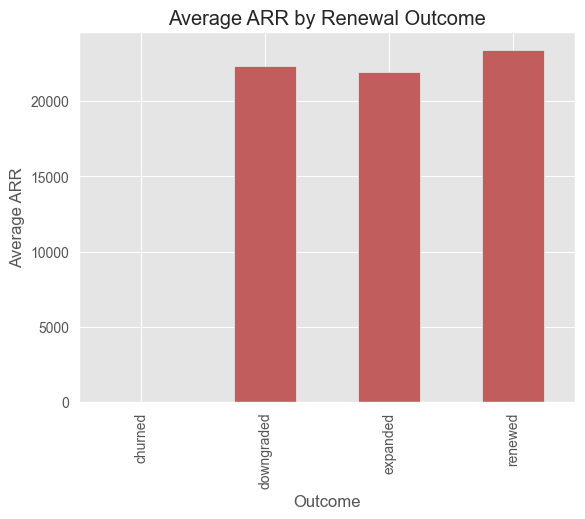

In [31]:
renewals.groupby("outcome")["new_arr"].mean()


plt.figure()

renewals.groupby("outcome")["new_arr"].mean().plot(kind="bar",color="#C25D5D")

plt.title("Average ARR by Renewal Outcome")

plt.xlabel("Outcome")

plt.ylabel("Average ARR")

plt.show()

<font color="purple" size="4"><b>Renewal Outcome vs Support Activity</b></font>

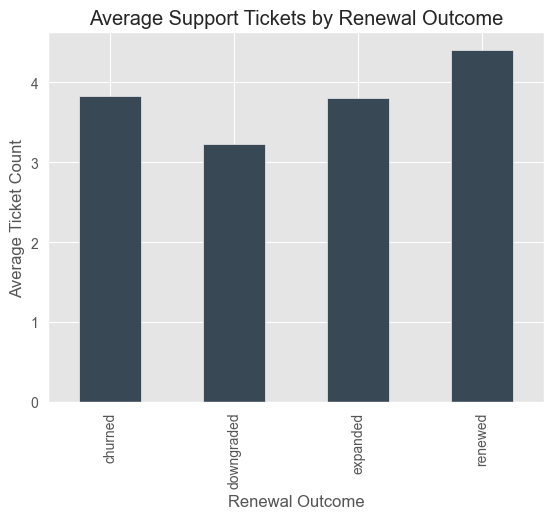

In [35]:
plt.figure()

support_renewals.groupby("outcome")["ticket_count"].mean().plot(kind="bar",color="#394855")

plt.title("Average Support Tickets by Renewal Outcome")
plt.xlabel("Renewal Outcome")
plt.ylabel("Average Ticket Count")

plt.show()

 <font color="orange" size="4"><b>Business Insight:</b></font>

If churned customers have higher ticket volumes, it suggests unresolved issues may contribute to customer churn.

<font color="purple" size="5"><b>Segmentation Analysis</b></font>

<font color="purple" size="4"><b>Usage Pattern Segmentation</b></font>


To better understand customer behavior, accounts are segmented into three groups:

- Low usage
- Medium usage
- High usage

Segmentation helps identify which types of users generate the most revenue.

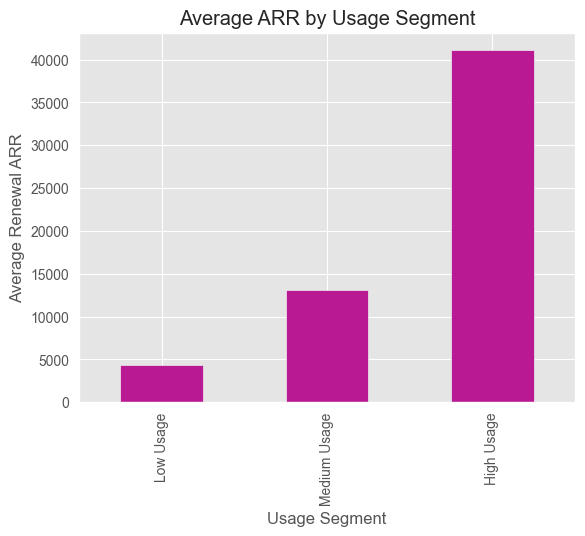

In [32]:
usage_per_account["usage_segment"] = pd.qcut(
    usage_per_account["usage_count"],
    q=3,
    labels=["Low Usage","Medium Usage","High Usage"]
)

usage_segment = usage_per_account.merge(renewals, on="account_id")

plt.figure()

usage_segment.groupby("usage_segment")["new_arr"].mean().plot(kind="bar",color="#B91A94")

plt.title("Average ARR by Usage Segment")
plt.xlabel("Usage Segment")
plt.ylabel("Average Renewal ARR")

plt.show()


<font color="orange" size="4"><b>Business Insight:</b></font>

High‑usage accounts generate significantly higher renewal ARR.

This indicates that **product engagement is strongly linked to customer value and retention**.


<font color="purple" size="4"><b>Key Insights</b></font>


• Accounts with higher product usage tend to generate higher renewal ARR.

• A higher number of support tickets may indicate potential customer issues.

• Higher NPS scores are associated with stronger renewal performance.

• Some regions generate significantly higher revenue than others.

• Enterprise tier customers typically contribute the largest share of ARR.

• Usage segmentation reveals that high engagement customers generate the highest revenue.

• Payment delays could indicate financial risk among certain accounts.

============================================================================


<font color="purple" size="6"><b>KPI_Engineering</b></font>
<br>


This section focuses on defining and calculating the key performance indicators (KPIs) used to evaluate the health and growth of a SaaS business.

The goal is to transform raw operational data into actionable business metrics that describe revenue performance, customer retention, operational efficiency, and customer satisfaction.

Each KPI in this section includes:

- The **formula** used to calculate the metric
- The **business logic** behind the calculation
- Any **caveats or assumptions** that may affect interpretation
- The **Python or SQL implementation**

The KPIs covered include revenue metrics (ARR, MRR, NRR, GRR), customer behavior indicators (churn, expansion, lifetime value), operational performance metrics (DSO, support ticket rate), and customer satisfaction indicators (NPS).

These metrics provide a comprehensive view of SaaS performance and are commonly used by leadership teams to guide strategic decisions.

<font color="purple" size="4"><b>Import Libraries</b></font>

In [39]:
import pandas as pd
import sqlite3

<font color="purple" size="4"><b>Load Data from SQLite Database</b></font>

In [40]:
# Load data from SQLite database
# This section connects to the SQLite database and loads each table into a pandas DataFrame for analysis.

conn = sqlite3.connect("../Data/data_cleaned.db")

accounts = pd.read_sql("SELECT * FROM accounts_dim", conn)
usage = pd.read_sql("SELECT * FROM usage_dim", conn)
support = pd.read_sql("SELECT * FROM support_dim", conn)
nps = pd.read_sql("SELECT * FROM nps_dim", conn)
renewals = pd.read_sql("SELECT * FROM renewals_fact", conn)
invoices = pd.read_sql("SELECT * FROM invoices_fact", conn)

<font color="purple" size="4"><b>Annual Recurring Revenue (ARR) and Monthly Recurring Revenue (MRR)</b></font>

**Formula:**

ARR = Sum of recurring subscription revenue across all active accounts

MRR = ARR / 12

**Logic:** Annual Recurring Revenue (ARR) represents the total predictable subscription revenue generated by customers over a one-year period. 

It is one of the primary revenue metrics used by SaaS companies to measure the size and growth of their subscription business.

Monthly Recurring Revenue (MRR) is the monthly equivalent of ARR and is commonly used to track short-term revenue trends and monthly growth.

**Caveats:** ARR assumes that all revenue is recurring and annualized. One-time charges, implementation fees, or usage-based revenue are not included in ARR calculations.

In addition, if contracts have different billing cycles (monthly vs annual), ARR may simplify these differences by annualizing revenue.

In [45]:
total_arr = accounts["arr"].sum()

mrr = total_arr / 12

print("Total ARR:", total_arr)
print("MRR:", mrr)

Total ARR: 11671842
MRR: 972653.5


<font color="purple" size="4"><b>Net Revenue Retention (NRR)</b></font>

**Formula:**

NRR = (Ending ARR from existing customers) / (Starting ARR from those same customers)

**Alternative expression:**

NRR = (Starting ARR + Expansion − Contraction − Churn) / Starting ARR

**Logic:** Net Revenue Retention measures how revenue from existing customers changes over time.

It captures the combined impact of expansions, downgrades, and churn.

NRR above 100% indicates that expansion revenue from existing customers outweighs revenue lost from churn and downgrades, which is a strong indicator of healthy SaaS growth.

**Caveats:** NRR excludes revenue from newly acquired customers. It focuses only on revenue changes among the existing customer base.

In [46]:
starting_arr = renewals["previous_arr"].sum()

ending_arr = renewals["new_arr"].sum()

nrr = ending_arr / starting_arr

print("Net Revenue Retention:", nrr.round(3))

NRR: 0.844


<font color="purple" size="4"><b>Gross Revenue Retention (GRR)</b></font>

**Formula:**

GRR = (Starting ARR − Churn − Contraction) / Starting ARR

**Logic:** Gross Revenue Retention measures the percentage of recurring revenue retained from existing customers after accounting for churn and downgrades, but excluding any expansion revenue.

Unlike NRR, GRR cannot exceed 100% because expansions are not included.

GRR is commonly used to measure the stability of the customer base and the company's ability to retain existing revenue.

**Caveats:** GRR does not reflect revenue growth from upgrades or expansions. 

A company may have strong GRR but still experience slow revenue growth if expansion revenue is limited.

In [64]:
# Limit new ARR to previous ARR to remove expansion effect

adjusted_arr = renewals[["previous_arr", "new_arr"]].min(axis=1)

grr = adjusted_arr.sum() / renewals["previous_arr"].sum()

print("Gross Revenue Retention:", grr.round(3))

Gross Revenue Retention: 0.828


<font color="purple" size="4"><b>Churn Rate by Cohort</b></font>

**Formula:**

Churn Rate = Number of Churned Accounts / Total Accounts in Cohort

**Logic:** Cohort analysis groups customers based on a shared characteristic, such as the year they started their contract.

Churn rate by cohort helps identify whether customers acquired during specific periods tend to churn more frequently than others.

This type of analysis is commonly used in SaaS businesses to evaluate the effectiveness of onboarding, product adoption, and customer success initiatives over time.

**Caveats:** Cohorts with a small number of accounts may produce unstable churn estimates.

In addition, newer cohorts may appear to have lower churn simply because they have had less time to churn.

In [65]:
# Convert contract start to datetime
accounts["contract_start"] = pd.to_datetime(accounts["contract_start"])

# Create cohort year
accounts["cohort_year"] = accounts["contract_start"].dt.year

# Identify churned accounts
churned_accounts = renewals[renewals["outcome"] == "churned"]["account_id"]

accounts["churned"] = accounts["account_id"].isin(churned_accounts)

# Calculate churn rate by cohort
churn_by_cohort = accounts.groupby("cohort_year")["churned"].mean()

print(churn_by_cohort)

cohort_year
2024    0.139108
2025    0.176471
Name: churned, dtype: float64


In [67]:
# Calculate overall churn rate

churn = renewals[renewals["outcome"] == "churned"]

churn_rate = churn.groupby("account_id").size().count() / accounts.shape[0]

print("Churn rate:", churn_rate)

Churn rate: 0.148


<font color="purple" size="4"><b>Average Contract Value (ACV)</b></font>

**Formula:**

ACV = Total ARR / Number of Accounts

**Logic:** ACV represents the average annual subscription value generated per customer account. 

It helps understand the typical contract size and is commonly used in SaaS businesses to evaluate customer value and sales performance.

**Caveats:** ACV assumes that all revenue is recurring and annualized.

If contracts vary significantly in duration (monthly vs annual), ACV may not fully reflect revenue variability.

In [71]:
# Average Contract Value
acv = accounts["arr"].mean()

print("Average Contract Value (ACV):", acv)

Average Contract Value (ACV): 23343.684


<font color="purple" size="4"><b>Expansion MRR</b></font>

**Formula:**

Expansion MRR = Sum of positive ARR increases / 12

**Logic:** Expansion MRR captures additional recurring revenue generated from existing customers through upgrades, add-ons, or increased usage.

**Caveats:** Expansion MRR does not include revenue from new customer acquisition.

It only reflects growth within the existing customer base.

In [70]:
# identify expansions
expansion = renewals[renewals["new_arr"] > renewals["previous_arr"]]

# calculate ARR increase
expansion["arr_increase"] = expansion["new_arr"] - expansion["previous_arr"]

# expansion MRR
expansion_mrr = expansion["arr_increase"].sum() / 12

print("Expansion MRR:", expansion_mrr.round(3))

Expansion MRR: 16394.976


<font color="purple" size="4"><b>LTV / CAC (Proxy)</b></font>

**Formula:**

Customer Lifetime Value (LTV) = ACV × Average Customer Lifetime

LTV / CAC = Customer Lifetime Value / Customer Acquisition Cost

**Logic:** The LTV/CAC ratio measures the efficiency of customer acquisition by comparing the total value generated by a customer during their lifetime with the cost required to acquire that customer.

Because the dataset does not include explicit customer acquisition costs (CAC), a proxy approach is used. In this analysis, CAC is approximated using a simplified assumption based on the average contract value.

**Caveats:** The dataset does not contain actual sales and marketing acquisition costs, therefore CAC must be estimated using a proxy. 

In this analysis, CAC is approximated as a fraction of ACV.

As a result, the calculated LTV/CAC ratio should be interpreted as an indicative metric rather than a precise financial measure.


Since CAC data is not available in the dataset, the ratio is calculated using an estimated CAC proxy for illustrative analytical purposes.

In [68]:
# Average Contract Value
acv = accounts["arr"].mean()

# assumed average lifetime (years)
avg_customer_lifetime = 3

# LTV
ltv = acv * avg_customer_lifetime

# CAC proxy
cac_proxy = acv / 3

# LTV / CAC
ltv_cac_ratio = ltv / cac_proxy

print("ACV:", acv)
print("Estimated LTV:", ltv)
print("Estimated CAC:", cac_proxy)
print("LTV/CAC Ratio:", ltv_cac_ratio)

ACV: 23343.684
Estimated LTV: 70031.052
Estimated CAC: 7781.228
LTV/CAC Ratio: 9.0


<font color="purple" size="4"><b>Days Sales Outstanding (DSO) by Region</b></font>

**Formula:**

DSO = Average (Payment Date − Invoice Date)

**Logic:** Days Sales Outstanding measures how long it takes on average for customers to pay their invoices after they are issued.

A lower DSO indicates faster cash collection and better financial efficiency, while a higher DSO may signal delayed payments or collection challenges.

Analyzing DSO by region helps identify geographic differences in payment behavior.

**Caveats:** DSO does not account for invoice size or payment terms (e.g., Net 30 vs Net 60).

If invoices remain unpaid or missing payment dates exist, the metric may underestimate actual payment delays.

In [72]:
# convert to datetime
invoices["invoice_date"] = pd.to_datetime(invoices["invoice_date"])
invoices["paid_date"] = pd.to_datetime(invoices["paid_date"])

# calculate days to payment
invoices["days_to_pay"] = (invoices["paid_date"] - invoices["invoice_date"]).dt.days

# merge region info
dso_data = invoices.merge(accounts[["account_id","region"]], on="account_id")

# calculate DSO by region
dso_by_region = dso_data.groupby("region")["days_to_pay"].mean()

print(dso_by_region)

region
APAC             37.048611
Europe           37.187387
North America    36.800813
Name: days_to_pay, dtype: float64


<font color="purple" size="4"><b>Support Ticket Rate</b></font>

**Formula:**

Support Ticket Rate = Total Support Tickets / Total Number of Accounts

**Logic:** This KPI measures how frequently customers require support assistance. 

A higher ticket rate may indicate product complexity, usability issues, or operational challenges.

**Caveats:** Support volume may be influenced by customer size. 

Large enterprise customers may naturally generate more tickets, which can skew the metric if not normalized by account size or usage.

In [74]:
# tickets per account
tickets_per_account = support.groupby("account_id").size()

# average ticket rate
support_ticket_rate = tickets_per_account.mean()

print("Support Ticket Rate per Account:", support_ticket_rate.round(3))

Support Ticket Rate per Account: 4.094


In [75]:
# calculate overall ticket rate
total_tickets = support.shape[0]
total_accounts = accounts.shape[0]

ticket_rate = total_tickets / total_accounts

print("Ticket Rate:", ticket_rate)

Ticket Rate: 4.004


<font color="purple" size="4"><b>NPS by Segment</b></font>

**Formula:**

NPS = % Promoters − % Detractors

Promoters: score ≥ 9  
Passives: score 7–8  
Detractors: score ≤ 6

**Logic:** Net Promoter Score (NPS) measures customer loyalty by comparing the proportion of promoters to detractors.

In this analysis, NPS responses are first classified into promoter, passive, and detractor categories. 

The NPS score is then calculated based on the share of promoters minus detractors.

Segmenting responses allows the business to analyze customer sentiment across different groups.

**Caveats:** Only 34% of customers responded to the NPS survey, which introduces potential non-response bias. Respondents may not represent the entire customer base.

In [85]:
# classify responses
nps["segment"] = pd.cut(
    nps["score"],
    bins=[0,6,8,10],
    labels=["Detractor","Passive","Promoter"]
)

# calculate proportions
nps_distribution = nps["segment"].value_counts(normalize=True)

promoters = nps_distribution.get("Promoter",0)
detractors = nps_distribution.get("Detractor",0)

# calculate NPS
nps_score = (promoters - detractors) * 100

print("NPS Score:", nps_score.round(3),"\n")
print(nps_distribution.round(3),"\n")

# calculate segment counts
nps_segment = nps.groupby("segment").size()

print(nps_segment)

NPS Score: -38.028 

segment
Detractor    0.585
Passive      0.211
Promoter     0.204
Name: proportion, dtype: float64 

segment
Detractor    83
Passive      30
Promoter     29
dtype: int64


<font color="purple" size="4"><b>Time to Churn After Downgrade</b></font>

**Formula:**

Time to Churn = Churn Date − First Downgrade Date

**Logic:**

This metric measures the time between the first downgrade in a customer's contract value and the eventual churn event.

Downgrades may act as an early warning signal that the customer is reducing product usage or value perception before leaving entirely.

Understanding the typical time between downgrade and churn helps customer success teams intervene earlier.

**Caveats:**

Not all downgrades result in churn. Some customers may downgrade temporarily and later expand again.

In datasets with limited renewal history, the first observed downgrade may not actually be the customer's first downgrade event.

In [89]:
# identify downgrades
downgrades = renewals[renewals["new_arr"] < renewals["previous_arr"]]

# keep only churned accounts
downgrade_churn = downgrades[downgrades["outcome"] == "churned"]

# convert date
downgrade_churn["renewal_date"] = pd.to_datetime(downgrade_churn["renewal_date"])
accounts["contract_start"] = pd.to_datetime(accounts["contract_start"])

# merge contract start
downgrade_churn = downgrade_churn.merge(
    accounts[["account_id","contract_start"]],
    on="account_id"
)

# time difference
downgrade_churn["time_to_churn_days"] = (
    downgrade_churn["renewal_date"] - downgrade_churn["contract_start"]
).dt.days

print("Average Time to Churn After Downgrade:",
      downgrade_churn["time_to_churn_days"].mean().round(3))

Average Time to Churn After Downgrade: 87.689


<font color="purple" size="4"><b>KPI Summary and Business Interpretation</b></font>

The calculated KPIs provide a multi-dimensional view of the SaaS business performance across revenue growth, customer retention, operational efficiency, and customer satisfaction.

Key insights derived from the KPI analysis include:

**Revenue Performance**
Recurring revenue metrics such as ARR, MRR, Net Revenue Retention (NRR), and Gross Revenue Retention (GRR) provide insight into the stability and growth of the subscription base. High NRR indicates that expansion revenue from existing customers offsets losses from churn or contraction.

**Customer Retention and Churn**
Churn rate by cohort helps identify patterns in customer retention over time. Tracking churn relative to contract start cohorts allows the business to evaluate the effectiveness of onboarding and early customer success efforts.

**Customer Value**
Average Contract Value (ACV) and the estimated LTV/CAC ratio help measure the economic value generated by each customer and the efficiency of customer acquisition.

**Revenue Expansion** 
Expansion MRR highlights revenue growth driven by existing customers upgrading their subscriptions or increasing usage, which is a key driver of SaaS scalability.

**Operational Efficiency** 
Days Sales Outstanding (DSO) provides insight into how efficiently the company collects payments. Longer payment cycles may affect cash flow and financial stability.

**Customer Support Load**  
Support ticket rate per account helps identify potential product usability challenges or operational bottlenecks.

**Customer Satisfaction**  
NPS scores help evaluate overall customer sentiment and loyalty. However, the relatively low survey response rate should be considered when interpreting these results.

Overall, these KPIs collectively provide a framework for monitoring business health, identifying growth opportunities, and detecting operational risks in a subscription-based SaaS environment.

============================================================================

<font color="purple" size="6"><b>Churn Prediction Model</b></font>

The objective of this analysis is to build a machine learning model capable of identifying customer accounts at risk of churning.

Churn prediction is critical for SaaS businesses because retaining existing customers is significantly more cost-effective than acquiring new ones.

The model will be trained using historical account activity, including usage behavior, support interactions, billing patterns, and customer satisfaction signals.

The goal is to identify early warning signals that indicate a higher probability of churn.

<font color="purple" size="4"><b>Churn Label Definition</b></font>

In this dataset, churn is defined as accounts where the renewal outcome is labeled as "churned".

**Label Definition:**

Churn = 1 if renewal outcome = churned  
Churn = 0 otherwise

**Limitations:**

This definition assumes churn occurs only at contract renewal events. Customers who reduce usage but remain active are not considered churned.

In [91]:
# create churn label
renewals["churn"] = (renewals["outcome"] == "churned").astype(int)

churn_rate = renewals["churn"].mean()

print("Churn Rate:", churn_rate.round(3))

Churn Rate: 0.147


<font color="purple" size="4"><b>Feature Engineering</b></font>

In [92]:
# usage features
usage_features = usage.groupby("account_id").agg(
    total_usage=("usage_count","sum"),
    avg_usage=("usage_count","mean")
).reset_index()

# support features
support_features = support.groupby("account_id").agg(
    ticket_count=("ticket_id","count"),
    avg_resolution=("resolution_hours","mean"),
    avg_sentiment=("sentiment_score","mean")
).reset_index()

# invoice features
invoices["invoice_date"] = pd.to_datetime(invoices["invoice_date"])
invoices["paid_date"] = pd.to_datetime(invoices["paid_date"])

invoices["days_to_pay"] = (invoices["paid_date"] - invoices["invoice_date"]).dt.days

invoice_features = invoices.groupby("account_id").agg(
    avg_days_to_pay=("days_to_pay","mean"),
    total_revenue=("amount","sum")
).reset_index()

# nps features
nps_features = nps.groupby("account_id").agg(
    avg_nps=("score","mean")
).reset_index()

# merge features
features = accounts.merge(usage_features,on="account_id",how="left")
features = features.merge(support_features,on="account_id",how="left")
features = features.merge(invoice_features,on="account_id",how="left")
features = features.merge(nps_features,on="account_id",how="left")
features = features.merge(renewals[["account_id","churn"]],on="account_id")

<font color="purple" size="4"><b>Train/Test Split</b></font>

In [93]:
from sklearn.model_selection import train_test_split

X = features.drop(columns=["account_id","company","account_manager","churn"])
y = features["churn"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,random_state=42
)

<font color="purple" size="4"><b>Train Two Models</b></font>

<font color="purple" size="3.5"><b>Logistic Regression</b></font>